# 🛒 Customer Segmentation

K-Means clustering on synthetic customer data with a **live UI** to add customers and explore segments.

| Feature | Range |
|---|---|
| Age | 18 – 70 |
| Annual Income (\$k) | 15 – 140 |
| Spending Score | 1 – 100 |
| Purchase Frequency (/ month) | 1 – 30 |


## 1. Install & Import

In [1]:
# Colab already has most of these; ipywidgets just needs enabling
!pip install -q ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings, io, base64
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Libraries ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.9 MB/s eta 0:00:00
✅ Libraries ready.


## 2. Generate Synthetic Data

In [2]:
np.random.seed(42)

seg1 = pd.DataFrame({'Age': np.random.randint(18,30,80), 'Annual_Income_k': np.random.randint(20,45,80),
                     'Spending_Score': np.random.randint(60,100,80), 'Purchase_Frequency': np.random.randint(10,20,80)})
seg2 = pd.DataFrame({'Age': np.random.randint(30,50,80), 'Annual_Income_k': np.random.randint(80,140,80),
                     'Spending_Score': np.random.randint(65,100,80), 'Purchase_Frequency': np.random.randint(15,25,80)})
seg3 = pd.DataFrame({'Age': np.random.randint(45,70,70), 'Annual_Income_k': np.random.randint(70,120,70),
                     'Spending_Score': np.random.randint(10,40,70), 'Purchase_Frequency': np.random.randint(2,8,70)})
seg4 = pd.DataFrame({'Age': np.random.randint(25,55,70), 'Annual_Income_k': np.random.randint(15,40,70),
                     'Spending_Score': np.random.randint(10,45,70), 'Purchase_Frequency': np.random.randint(3,10,70)})

df = pd.concat([seg1, seg2, seg3, seg4], ignore_index=True)
df['CustomerID'] = ['C' + str(i+1).zfill(4) for i in range(len(df))]
df = df[['CustomerID','Age','Annual_Income_k','Spending_Score','Purchase_Frequency']]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
display(df.head(8).style.set_caption('Sample rows'))

Dataset shape: (300, 5)


,CustomerID,Age,Annual_Income_k,Spending_Score,Purchase_Frequency
0,C0204,62,84,30,2
1,C0267,54,23,13,5
2,C0153,33,89,78,17
3,C0010,28,42,72,17
4,C0234,45,15,26,4
5,C0227,60,86,34,4
6,C0197,63,74,36,2
7,C0110,44,127,87,19


## 3. EDA

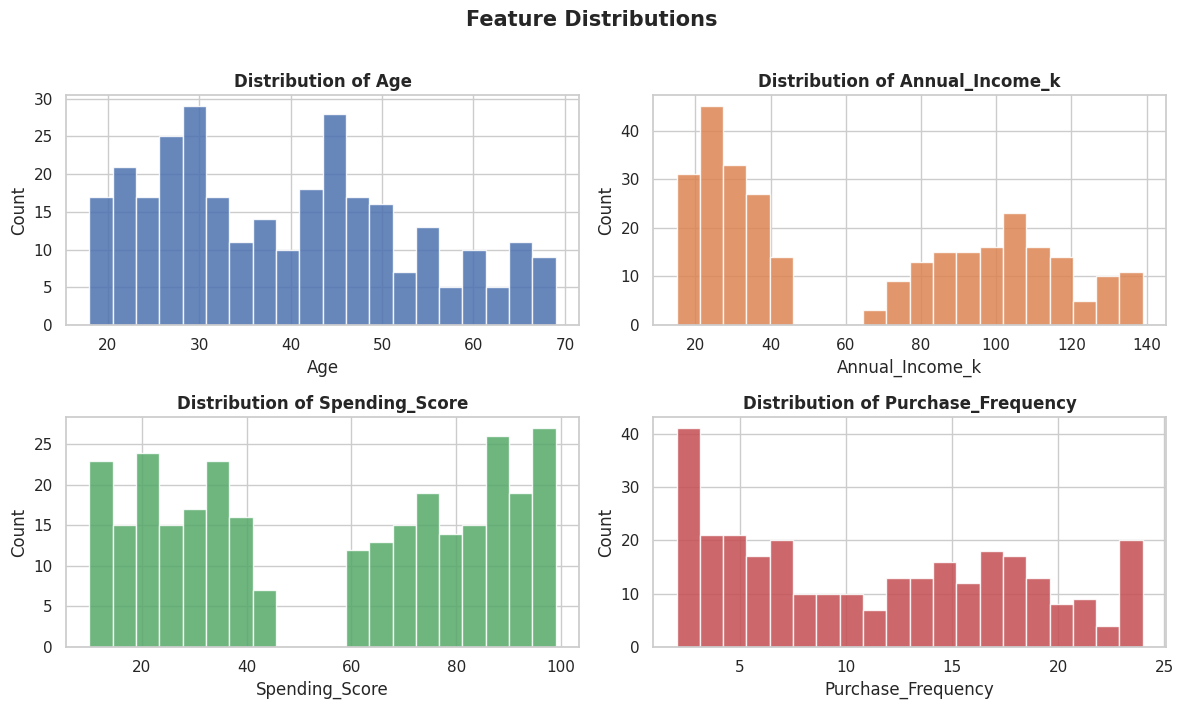

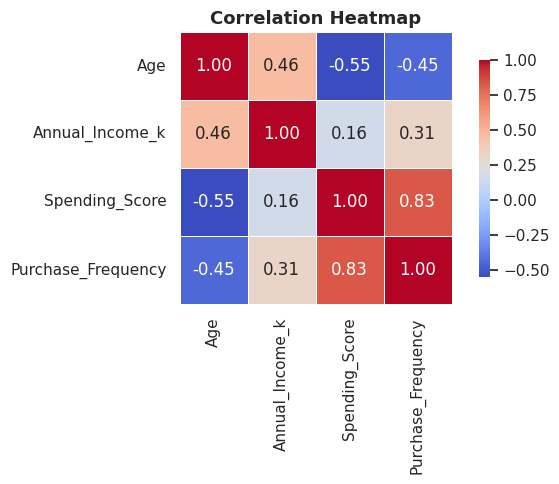

In [3]:
features = ['Age','Annual_Income_k','Spending_Score','Purchase_Frequency']
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for col, ax, c in zip(features, axes.flatten(), colors):
    ax.hist(df[col], bins=20, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Count')
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Scale & Find Optimal k

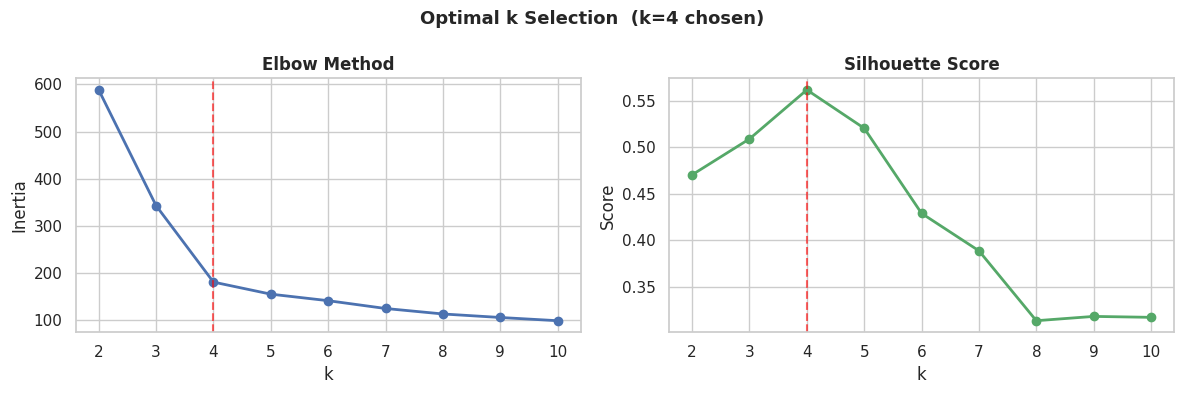

Optimal k = 4


In [4]:
X = df[features].copy()
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-', linewidth=2); ax1.axvline(4, color='red', ls='--', alpha=0.6)
ax1.set_title('Elbow Method', fontweight='bold'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax2.plot(K_range, silhouettes, 'go-', linewidth=2); ax2.axvline(4, color='red', ls='--', alpha=0.6)
ax2.set_title('Silhouette Score', fontweight='bold'); ax2.set_xlabel('k'); ax2.set_ylabel('Score')
plt.suptitle('Optimal k Selection  (k=4 chosen)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Optimal k = 4')

## 5. Train K-Means (k=4)

In [5]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

segment_labels = {
    0: '💎 Premium Customers',
    1: '🛍️ Impulse Buyers',
    2: '💰 Savers / High Earners',
    3: '🏷️ Budget Shoppers'
}
df['Segment'] = df['Cluster'].map(segment_labels)

# PCA for visualisation
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_scaled)

palette = ['#4C72B0','#DD8452','#55A868','#C44E52']

print('✅ Model trained.')
print(df.groupby('Segment')[features].mean().round(1).to_string())

✅ Model trained.
                          Age  Annual_Income_k  Spending_Score  Purchase_Frequency
Segment                                                                           
🏷️ Budget Shoppers       39.1             25.3            26.5                 5.8
💎 Premium Customers      39.0            110.6            83.8                19.7
💰 Savers / High Earners  23.8             30.9            79.6                14.1
🛍️ Impulse Buyers        57.5             93.5            25.3                 4.4


## 6. Cluster Visualisation

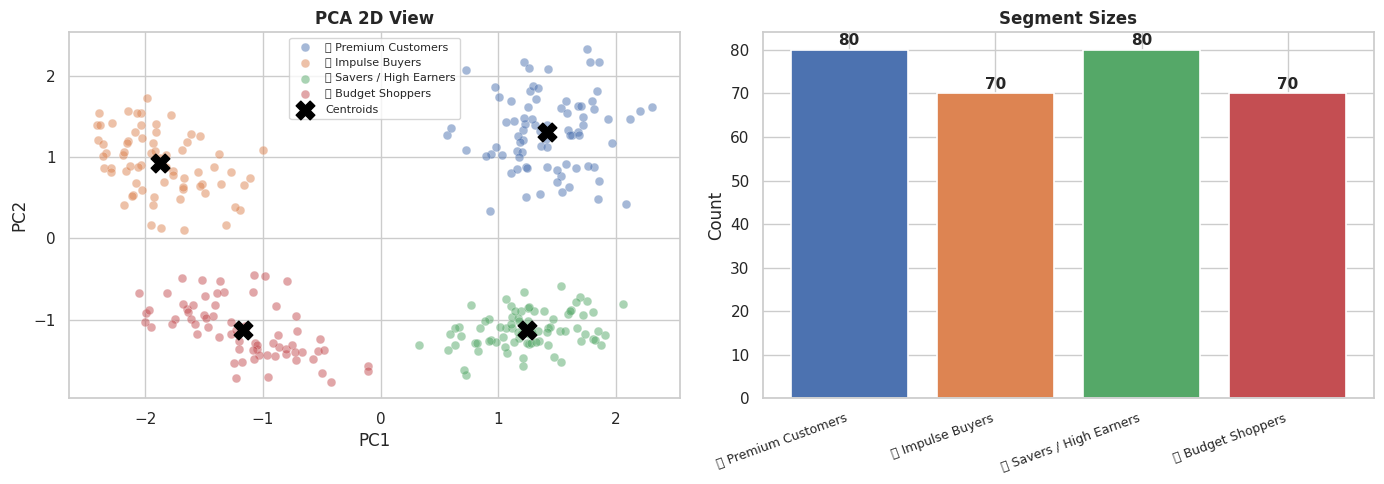

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
ax = axes[0]
for cid in range(K):
    mask = df['Cluster'] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=palette[cid],
               label=segment_labels[cid], alpha=0.5, s=40, edgecolors='white', lw=0.3)
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:,0], centroids_pca[:,1], c='black', marker='X', s=180, zorder=5, label='Centroids')
ax.set_title('PCA 2D View', fontweight='bold'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8, loc='best')

# Segment sizes
ax2 = axes[1]
counts = df['Cluster'].value_counts().sort_index()
bars = ax2.bar([segment_labels[i] for i in counts.index], counts.values,
               color=palette, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, counts.values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(v), ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Segment Sizes', fontweight='bold')
ax2.set_ylabel('Count'); plt.setp(ax2.get_xticklabels(), rotation=20, ha='right', fontsize=9)

plt.tight_layout(); plt.show()

## 7. Radar Profiles

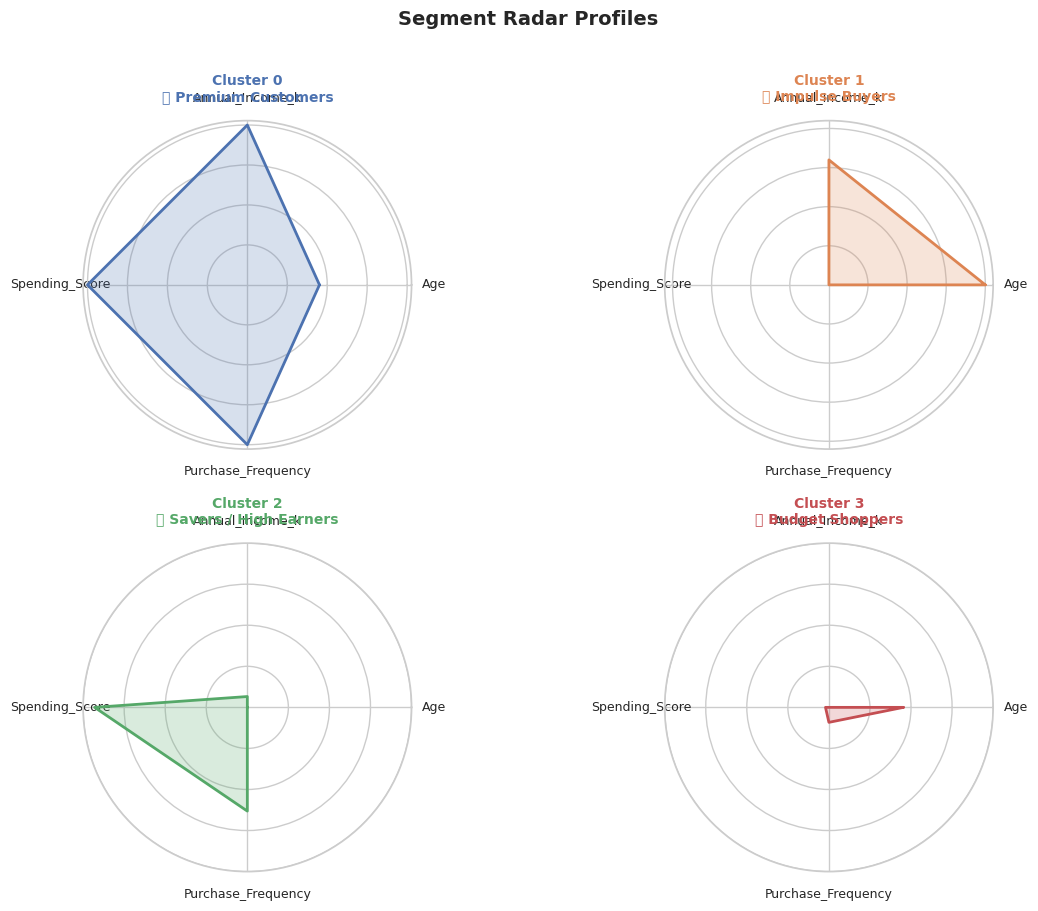

In [7]:
radar_data = df.groupby('Cluster')[features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist() + [0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), subplot_kw=dict(polar=True))
for idx, (ax, cid, c) in enumerate(zip(axes.flatten(), range(K), palette)):
    vals = radar_norm.loc[cid].tolist() + [radar_norm.loc[cid].tolist()[0]]
    ax.plot(angles, vals, color=c, linewidth=2)
    ax.fill(angles, vals, color=c, alpha=0.22)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(features, size=9)
    ax.set_yticks([0.25,0.5,0.75,1.0]); ax.set_yticklabels([])
    ax.set_title(f'Cluster {cid}\n{segment_labels[cid]}', size=10, fontweight='bold', pad=14, color=c)
plt.suptitle('Segment Radar Profiles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 8. 🎛️ Interactive Customer Dashboard

Use the sliders below to define a customer profile and hit **Classify**.  
Results, PCA position, and a running log of all added customers are shown live.

In [8]:
# ── Styling helpers ─────────────────────────────────────────────────────────
SEG_COLORS_HEX = ['#4C72B0','#DD8452','#55A868','#C44E52']
SEG_ICONS      = ['💎','🛍️','💰','🏷️']
TIPS = {
    '💎 Premium Customers'   : 'Loyalty rewards, VIP programs & exclusive early access.',
    '🛍️ Impulse Buyers'      : 'Flash sales, limited-time deals & trending products.',
    '💰 Savers / High Earners': 'Emphasise value, quality & long-term ROI.',
    '🏷️ Budget Shoppers'     : 'Promote discounts, bundles & affordable lines.',
}

customer_log = []

# ── Widgets ──────────────────────────────────────────────────────────────────
style  = {'description_width': '180px'}
layout = widgets.Layout(width='480px')

w_age    = widgets.IntSlider(value=35, min=18, max=70,  step=1,  description='Age (years)',           style=style, layout=layout)
w_income = widgets.IntSlider(value=85, min=15, max=140, step=1,  description='Annual Income ($k)',    style=style, layout=layout)
w_spend  = widgets.IntSlider(value=72, min=1,  max=100, step=1,  description='Spending Score (1–100)',style=style, layout=layout)
w_freq   = widgets.IntSlider(value=18, min=1,  max=30,  step=1,  description='Purchase Freq / month',style=style, layout=layout)

btn_classify = widgets.Button(description='  Classify Customer', button_style='primary',
                              icon='search', layout=widgets.Layout(width='200px', height='38px'))
btn_clear    = widgets.Button(description='  Clear Log', button_style='warning',
                              icon='trash', layout=widgets.Layout(width='140px', height='38px'))
btn_export   = widgets.Button(description='  Export CSV', button_style='success',
                              icon='download', layout=widgets.Layout(width='140px', height='38px'))

out_result = widgets.Output()
out_plot   = widgets.Output()
out_log    = widgets.Output()

# ── Logic ────────────────────────────────────────────────────────────────────
def predict_customer(age, income, spend, freq):
    new_df     = pd.DataFrame([{'Age':age,'Annual_Income_k':income,'Spending_Score':spend,'Purchase_Frequency':freq}])
    new_scaled = scaler.transform(new_df)
    cluster    = int(kmeans.predict(new_scaled)[0])
    segment    = segment_labels[cluster]
    return cluster, segment, new_scaled

def show_result(cluster, segment, age, income, spend, freq):
    color = SEG_COLORS_HEX[cluster]
    icon  = SEG_ICONS[cluster]
    avg   = df.groupby('Cluster')[features].mean().round(1).loc[cluster]
    tip   = TIPS[segment]

    html = f"""
    <div style="border:1.5px solid {color};border-radius:10px;padding:16px 20px;margin:8px 0;max-width:560px;">
      <div style="display:flex;align-items:center;gap:12px;margin-bottom:12px;">
        <span style="font-size:28px;">{icon}</span>
        <div>
          <div style="font-size:18px;font-weight:700;color:{color};">{segment}</div>
          <div style="font-size:12px;color:#888;">Cluster {cluster}</div>
        </div>
      </div>
      <table style="border-collapse:collapse;width:100%;font-size:13px;">
        <tr style="border-bottom:1px solid #eee;">
          <th style="text-align:left;padding:5px 8px;color:#555;">Feature</th>
          <th style="text-align:center;padding:5px 8px;color:#555;">Your Input</th>
          <th style="text-align:center;padding:5px 8px;color:#555;">Segment Avg</th>
        </tr>
        <tr><td style="padding:4px 8px;">Age</td><td style="text-align:center;font-weight:600;">{age}</td><td style="text-align:center;color:#666;">{avg['Age']}</td></tr>
        <tr style="background:#f9f9f9;"><td style="padding:4px 8px;">Annual Income</td><td style="text-align:center;font-weight:600;">${income}k</td><td style="text-align:center;color:#666;">${avg['Annual_Income_k']}k</td></tr>
        <tr><td style="padding:4px 8px;">Spending Score</td><td style="text-align:center;font-weight:600;">{spend}</td><td style="text-align:center;color:#666;">{avg['Spending_Score']}</td></tr>
        <tr style="background:#f9f9f9;"><td style="padding:4px 8px;">Purchase Freq</td><td style="text-align:center;font-weight:600;">{freq}/mo</td><td style="text-align:center;color:#666;">{avg['Purchase_Frequency']}/mo</td></tr>
      </table>
      <div style="margin-top:12px;padding:8px 12px;background:{color}18;border-left:3px solid {color};border-radius:4px;font-size:12px;color:#333;">
        🎯 <strong>Strategy:</strong> {tip}
      </div>
    </div>
    """
    display(HTML(html))

def show_pca_plot(new_scaled, cluster, segment):
    pca_new = pca.transform(new_scaled)
    fig, ax = plt.subplots(figsize=(8, 5))
    for cid in range(K):
        mask = df['Cluster'] == cid
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=palette[cid],
                   label=segment_labels[cid], alpha=0.35, s=30, edgecolors='white', lw=0.2)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    ax.scatter(centroids_pca[:,0], centroids_pca[:,1], c='black', marker='X', s=160, zorder=5, label='Centroids')
    ax.scatter(pca_new[0,0], pca_new[0,1], c='yellow', marker='*', s=500, zorder=6,
               edgecolors='black', lw=1.2, label=f'⭐ New → {segment}')
    ax.annotate('  ← You', xy=(pca_new[0,0], pca_new[0,1]),
                fontsize=10, fontweight='bold', color='black',
                xytext=(pca_new[0,0]+0.2, pca_new[0,1]+0.2))
    ax.set_title(f'New Customer in Segment Space\nPredicted: {segment}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.legend(fontsize=8, loc='best')
    plt.tight_layout(); plt.show()

def show_log():
    if not customer_log:
        print('No customers added yet.')
        return
    log_df = pd.DataFrame(customer_log)
    display(log_df.style
            .set_caption(f'Customer Log  ({len(log_df)} entries)')
            .set_properties(**{'font-size':'12px'})
            .applymap(lambda v: f'color: {SEG_COLORS_HEX[[s for s in segment_labels.values()].index(v)]};font-weight:700'
                      if isinstance(v,str) and v in segment_labels.values() else '', subset=['Segment']))

# ── Callbacks ────────────────────────────────────────────────────────────────
def on_classify(b):
    age, income, spend, freq = w_age.value, w_income.value, w_spend.value, w_freq.value
    cluster, segment, new_scaled = predict_customer(age, income, spend, freq)

    customer_log.append({'#': len(customer_log)+1, 'Age': age, 'Income ($k)': income,
                         'Spending Score': spend, 'Freq/mo': freq, 'Segment': segment})
    with out_result:
        clear_output(wait=True)
        show_result(cluster, segment, age, income, spend, freq)
    with out_plot:
        clear_output(wait=True)
        show_pca_plot(new_scaled, cluster, segment)
    with out_log:
        clear_output(wait=True)
        show_log()

def on_clear(b):
    customer_log.clear()
    with out_result: clear_output()
    with out_plot:   clear_output()
    with out_log:    clear_output(); print('Log cleared.')

def on_export(b):
    if not customer_log:
        with out_log: clear_output(wait=True); print('Nothing to export yet.')
        return
    log_df = pd.DataFrame(customer_log)
    csv    = log_df.to_csv(index=False)
    b64    = base64.b64encode(csv.encode()).decode()
    link   = f'<a href="data:text/csv;base64,{b64}" download="customer_log.csv" style="font-size:14px;">📥 Click here to download customer_log.csv</a>'
    with out_log: clear_output(wait=True); display(HTML(link))

btn_classify.on_click(on_classify)
btn_clear.on_click(on_clear)
btn_export.on_click(on_export)

# ── Layout ───────────────────────────────────────────────────────────────────
header = widgets.HTML('<h3 style="margin:0 0 12px;">🎛️ Customer Profiler</h3>')
sliders = widgets.VBox([w_age, w_income, w_spend, w_freq], layout=widgets.Layout(margin='0 0 12px 0'))
buttons = widgets.HBox([btn_classify, btn_clear, btn_export], layout=widgets.Layout(gap='8px', margin='0 0 16px 0'))

log_header = widgets.HTML('<h4 style="margin:20px 0 8px;">📋 Customer Log</h4>')

display(widgets.VBox([
    header,
    sliders,
    buttons,
    out_result,
    out_plot,
    log_header,
    out_log
]))

## 9. Export Full Dataset

In [9]:
df['Segment_Label'] = df['Cluster'].map(segment_labels)
df.to_csv('customer_segments.csv', index=False)
print('✅ Full dataset saved to customer_segments.csv')

# Quick download link in Colab
import base64
csv_b64 = base64.b64encode(df.to_csv(index=False).encode()).decode()
display(HTML(f'<a href="data:text/csv;base64,{csv_b64}" download="customer_segments.csv" style="font-size:14px;">📥 Download customer_segments.csv</a>'))
display(df.head(10))

✅ Full dataset saved to customer_segments.csv


,CustomerID,Age,Annual_Income_k,Spending_Score,Purchase_Frequency,Cluster,Segment,Segment_Label
0,C0204,62,84,30,2,1,🛍️ Impulse Buyers,🛍️ Impulse Buyers
1,C0267,54,23,13,5,3,🏷️ Budget Shoppers,🏷️ Budget Shoppers
2,C0153,33,89,78,17,0,💎 Premium Customers,💎 Premium Customers
3,C0010,28,42,72,17,2,💰 Savers / High Earners,💰 Savers / High Earners
4,C0234,45,15,26,4,3,🏷️ Budget Shoppers,🏷️ Budget Shoppers
5,C0227,60,86,34,4,1,🛍️ Impulse Buyers,🛍️ Impulse Buyers
6,C0197,63,74,36,2,1,🛍️ Impulse Buyers,🛍️ Impulse Buyers
7,C0110,44,127,87,19,0,💎 Premium Customers,💎 Premium Customers
8,C0006,24,35,98,16,2,💰 Savers / High Earners,💰 Savers / High Earners
9,C0176,65,115,20,7,1,🛍️ Impulse Buyers,🛍️ Impulse Buyers


---
## 10. Business Insights

| Segment | Profile | Marketing Strategy |
|---|---|---|
| 💎 Premium Customers | High income · high spend · mid-age | Loyalty programs, VIP access, exclusive offers |
| 🛍️ Impulse Buyers | Low income · high spend · young | Flash sales, limited-time deals, trending products |
| 💰 Savers / High Earners | High income · low spend · older | Value propositions, quality messaging, trust-building |
| 🏷️ Budget Shoppers | Low income · low spend · mid-age | Discounts, bundles, affordable product lines |